# Tox21 — Analisi esplorativa

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt

from data import load_tox21, dataset_stats, TASK_NAMES
from plotstyle import use_project_style, SERIES, TEXT_SECONDARY, bar_labels

use_project_style()
FIGDIR = pathlib.Path.cwd().parent / "results" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

In [2]:
dataset, split_idx = load_tox21()
overall, rows = dataset_stats(dataset, split_idx)
overall

{'n_molecole': 7831,
 'n_task': 12,
 'perc_etichette_mancanti': 17.054016089899118,
 'n_train': 6264,
 'n_valid': 783,
 'n_test': 784}

## 1. Etichette mancanti e sbilanciamento

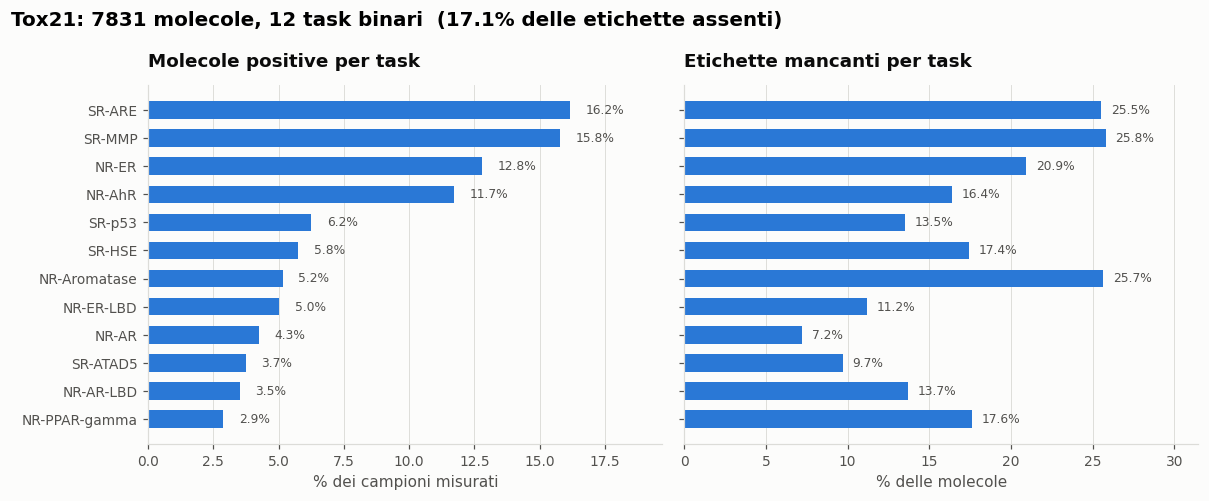

In [3]:
perc_pos = np.array([r["perc_positivi"] for r in rows])
perc_mis = np.array([r["perc_mancanti"] for r in rows])
order = np.argsort(perc_pos)            # ordinamento per leggibilita'
names = np.array(TASK_NAMES)[order]
y = np.arange(len(names))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)

# Una sola serie per pannello -> un solo colore per tutte le barre, niente legenda.
b1 = axes[0].barh(y, perc_pos[order], height=0.62, color=SERIES[0])
axes[0].set_title("Molecole positive per task")
axes[0].set_xlabel("% dei campioni misurati")
axes[0].set_xlim(0, max(perc_pos) * 1.22)
bar_labels(axes[0], b1)

b2 = axes[1].barh(y, perc_mis[order], height=0.62, color=SERIES[0])
axes[1].set_title("Etichette mancanti per task")
axes[1].set_xlabel("% delle molecole")
axes[1].set_xlim(0, max(perc_mis) * 1.22)
bar_labels(axes[1], b2)

axes[0].set_yticks(y, names)
for ax in axes:
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

fig.suptitle(f"Tox21: {overall['n_molecole']} molecole, 12 task binari  "
             f"({overall['perc_etichette_mancanti']:.1f}% delle etichette assenti)",
             x=0.005, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGDIR / "01_task_stats.png")
plt.show()

La percentuale di positivi varia da circa il 3% (NR-PPAR-gamma) al 16% (SR-ARE): tutti i task presentano uno sbilanciamento delle classi, ma con entità molto diverse. Un classificatore che predicesse sempre la classe negativa raggiungerebbe un’accuratezza compresa tra l’84% e il 97%; per questo l’accuratezza è poco informativa in questo contesto e adottiamo ROC-AUC e average precision (§5.2).

I task con la maggiore quantità di dati mancanti (circa il 26%) sono anche tra quelli con la maggiore percentuale di positivi. Le due difficoltà, quindi, non si concentrano sugli stessi task, rendendo il problema complessivamente meno critico.

Ogni molecola è stata sottoposta a un sottoinsieme dei 12 test disponibili. Di conseguenza, la matrice delle etichette contiene valori `NaN`, che indicano i casi in cui una determinata molecola non è stata testata per quella specifica etichetta.

## 2. Dimensione delle molecole

Rilevante per due scelte architetturali: il numero di layer di message passing (un
raggio di 5 hop su molecole di ~16 atomi copre già buona parte del grafo) e il
tipo di global pooling (la somma correla con il numero di atomi).

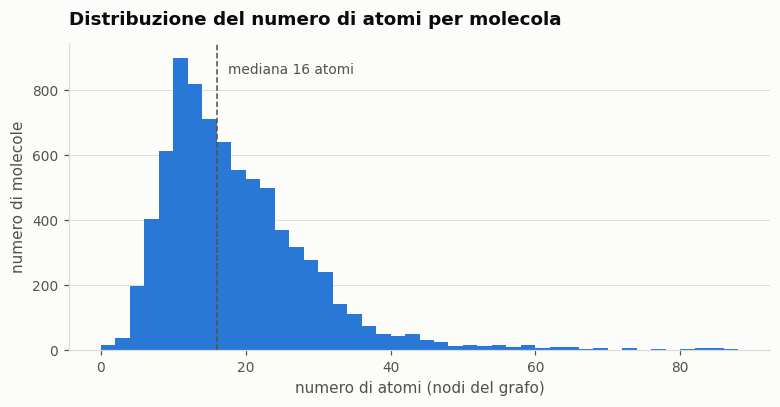

atomi  -> mediana 16, media 18.6, min 1, max 132
legami -> mediana 17, media 19.3
molecole aventi meno di 5 atomi: 123


In [4]:
n_atoms = np.array([d.num_nodes for d in dataset])
n_bonds = np.array([d.edge_index.shape[1] // 2 for d in dataset])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.hist(n_atoms, bins=np.arange(0, 90, 2), color=SERIES[0])
ax.set_title("Distribuzione del numero di atomi per molecola")
ax.set_xlabel("numero di atomi (nodi del grafo)")
ax.set_ylabel("numero di molecole")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)

med = np.median(n_atoms)
ax.axvline(med, color=TEXT_SECONDARY, linewidth=1, linestyle="--")
ax.text(med + 1.5, ax.get_ylim()[1] * 0.9, f"mediana {med:.0f} atomi",
        color=TEXT_SECONDARY, fontsize=9)

fig.tight_layout()
fig.savefig(FIGDIR / "02_dimensione_molecole.png")
plt.show()

print(f"atomi  -> mediana {np.median(n_atoms):.0f}, media {n_atoms.mean():.1f}, "
      f"min {n_atoms.min()}, max {n_atoms.max()}")
print(f"legami -> mediana {np.median(n_bonds):.0f}, media {n_bonds.mean():.1f}")
print(f"molecole aventi meno di 5 atomi: {(n_atoms < 5).sum()}")

## 3. Effetto dello scaffold split

Lo **scaffold split** suddivide le molecole in base al loro scheletro strutturale, facendo sì che il set di test contenga strutture chimiche differenti da quelle osservate durante l’addestramento. Questo rende la valutazione più realistica, perché il modello deve generalizzare a molecole con caratteristiche strutturali non presenti nei dati di training.

Inoltre, se la percentuale di positivi varia tra training e test, lo sbilanciamento delle classi si combina con il **distribution shift**, rendendo il problema di classificazione più impegnativo. È proprio questa capacità di generalizzare a nuove strutture chimiche che lo scaffold split mira a valutare.


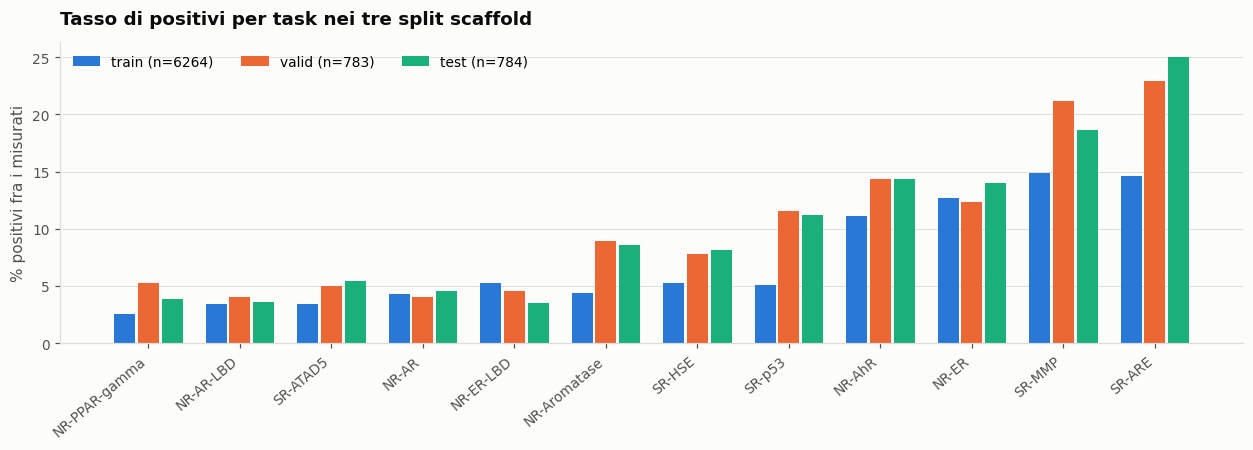

scarto medio |test - train| in punti percentuali: 3.11
scarto massimo: 10.40 (SR-ARE)


In [5]:
Y = torch.cat([d.y for d in dataset], dim=0).numpy()

def pos_rate(idx):
    y = Y[idx]
    valid = ~np.isnan(y)
    return np.array([100.0 * np.nansum(y[:, t] == 1) / max(valid[:, t].sum(), 1)
                     for t in range(y.shape[1])])

splits = ["train", "valid", "test"]
rates = {s: pos_rate(split_idx[s].numpy()) for s in splits}

x = np.arange(len(TASK_NAMES))
w = 0.26

fig, ax = plt.subplots(figsize=(11.5, 4.2))
for i, s in enumerate(splits):
    ax.bar(x + (i - 1) * w, rates[s][order], width=w - 0.03,
           color=SERIES[i], label=f"{s} (n={len(split_idx[s])})")

ax.set_title("Tasso di positivi per task nei tre split scaffold")
ax.set_ylabel("% positivi fra i misurati")
ax.set_xticks(x, names, rotation=40, ha="right")
ax.grid(axis="x", visible=False)
ax.set_axisbelow(True)
ax.legend(ncols=3, loc="upper left")

fig.tight_layout()
fig.savefig(FIGDIR / "03_split_scaffold.png")
plt.show()

print("scarto medio |test - train| in punti percentuali: "
      f"{np.abs(rates['test'] - rates['train']).mean():.2f}")
print("scarto massimo: "
      f"{np.abs(rates['test'] - rates['train']).max():.2f} "
      f"({TASK_NAMES[int(np.argmax(np.abs(rates['test'] - rates['train'])))]})")

Il tasso di positivi varia tra gli split: lo scaffold split introduce quindi una moderata variazione nella distribuzione delle classi tra train e test. Lo scarto medio è di 3,11 punti percentuali, mentre quello massimo raggiunge 10,40 punti percentuali per SR-ARE. La principale difficoltà dello scaffold split rimane comunque la presenza, nel test, di scaffold non osservati durante l’addestramento. Il confronto con uno split casuale permette quindi di valutare quanto questa maggiore distanza strutturale influenzi le prestazioni del modello

## 4. Struttura dei dati del dataset

Il codice mostra come sono codificate le informazioni nel dataset

In [7]:
d = dataset[0]
print(d)
print("\nx (primi 3 atomi):\n", d.x[:3])
print("\nedge_attr (primi 3 legami):\n", d.edge_attr[:3])
print("\ny:", d.y)

X = torch.cat([g.x for g in dataset[:2000]], dim=0)
print("\nvalori distinti per ciascuna delle 9 feature atomo:",
      [int(X[:, i].max()) + 1 for i in range(X.shape[1])])
E = torch.cat([g.edge_attr for g in dataset[:2000]], dim=0)
print("valori distinti per ciascuna delle 3 feature legame:",
      [int(E[:, i].max()) + 1 for i in range(E.shape[1])])

Data(edge_index=[2, 34], edge_attr=[34, 3], x=[16, 9], y=[1, 12], num_nodes=16)

x (primi 3 atomi):
 tensor([[5, 0, 4, 5, 3, 0, 2, 0, 0],
        [5, 0, 4, 5, 2, 0, 2, 0, 0],
        [7, 0, 2, 5, 0, 0, 1, 0, 0]])

edge_attr (primi 3 legami):
 tensor([[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]])

y: tensor([[0., 0., 1., nan, nan, 0., 0., 1., 0., 0., 0., 0.]])

valori distinti per ciascuna delle 9 feature atomo: [82, 3, 7, 9, 4, 4, 6, 2, 2]
valori distinti per ciascuna delle 3 feature legame: [4, 3, 2]


## Conclusioni della fase 1

1. **7831 molecole, 12 task, 17% di etichette assenti** → loss mascherata obbligatoria.
2. **Positivi fra 2.9% e 16.2%** → accuratezza inutilizzabile, si usa ROC-AUC + AP.
3. **Molecole piccole (mediana 16 atomi, media 18.6)** → 5 layer di message passing sono
   gia' tanti; l'ablation sul numero di layer (E5) ha senso. Attenzione alla coda:
   123 molecole hanno meno di 5 atomi (una ne ha 1, quindi grafo senza archi) — vanno
   gestite senza far crashare il pooling.
4. **Lo scaffold split sposta la distribuzione** → attendersi metriche piu' basse ma
   oneste; E6 quantifica la differenza rispetto allo split casuale.
5. **Feature categoriche** → servono `AtomEncoder`/`BondEncoder`.

